# 17 -- Hierarchical Risk Parity factor allocator

**Цель:** заменить **manual stepwise selection** (мой выбор Quality → Quarterly → Ensemble → Overlay
по Sharpe на main) на **algorithmic composition** через HRP.

**Methodology (De Prado 2016, JPM):**
1. Готовим **6 factor portfolios** — каждый long-only top-Q5 по своему фактору.
2. На каждую rebalance date: считаем 6×6 covariance matrix factor returns на past 252 days.
3. HRP даёт **веса** каждого factor portfolio (risk parity на cluster level).
4. Combo portfolio = weighted sum.

**Преимущества:**
- **Полная воспроизводимость** — нет subjective thresholds
- **Адаптация к режиму** — HRP пересчитывает weights каждый квартал
- **Защита от data snooping** — нет post-hoc cherry-pick из 23 variants
- **Опубликовано в JPM** — defensible methodology

**6 factor portfolios:**
1. **Mispricing** (CatBoost ensemble z) — наш main signal
2. **Quality** (composite z из 7 fundamental metrics)
3. **Momentum** (past 60-day price return)
4. **Low-volatility** (1 / realized_vol_60d)
5. **Carry** (raw g_spread highest)
6. **Issuer consensus** (issuer-level mispricing)

Все factor portfolios используют **те же** filters (tradable, quality-min) и same construction.

**Литература:**
- López de Prado (JPM 2016) — "Building Diversified Portfolios that Outperform Out of Sample"
- Markowitz (1952) — Mean-Variance optimization (baseline)
- Bailey, Borwein, López de Prado, Zhu (2014) — Probability of Backtest Overfitting

## Часть 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
from pathlib import Path

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import strategy_lib as sl

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 5), 'font.family': 'DejaVu Sans',
                      'axes.unicode_minus': False})
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

# Load enriched signal
sig = sl.load_signal_full('no_lag')
sig_wl = sl.load_signal_full('with_lag')
wl_sub = sig_wl[['date', 'isin', 'mispricing_z']].copy()
wl_sub.columns = ['date', 'isin', 'mispricing_z_wl']
sig = sig.merge(wl_sub, on=['date', 'isin'], how='inner')
sig['mispricing_z_nl'] = sig['mispricing_z']
sig['mispricing_avg_z'] = (sig['mispricing_z_nl'] + sig['mispricing_z_wl']) / 2
sig = sl.compute_quality_score(sig)
sig = sl.compute_momentum(sig, lookback_days=60)

# Realized vol (60d) — для low-vol factor
sig = sig.sort_values(['isin', 'date']).reset_index(drop=True)
sig['realized_vol_60d'] = sig.groupby('isin')['total_return'].transform(
    lambda s: s.rolling(60, min_periods=20).std())
sig['inv_vol'] = 1.0 / sig['realized_vol_60d'].replace(0, np.nan)

# Issuer consensus
sig = sl.compute_issuer_consensus(sig, z_col='mispricing_avg_z', blend_weight=1.0)

print(f'sig shape: {sig.shape}')
print(f'Coverage:')
for c in ['mispricing_avg_z', 'quality_z', 'mom_z', 'inv_vol', 'g_spread', 'issuer_consensus_z']:
    print(f'  {c:25s}: {sig[c].notna().mean():.1%}')

sig shape: (277966, 43)
Coverage:
  mispricing_avg_z         : 100.0%
  quality_z                : 77.5%
  mom_z                    : 72.1%
  inv_vol                  : 93.4%
  g_spread                 : 100.0%
  issuer_consensus_z       : 100.0%


## Часть 2. Построить 6 factor portfolios

Каждый — top-25 bonds по своему фактору, quarterly rebalance, equal-weight, tradable filter.

In [2]:
FACTOR_DEFS = [
    # (name, ranking_col, transform)
    ('mispricing',  'mispricing_avg_z',     None),
    ('quality',     'quality_z',             None),
    ('momentum',    'mom_z',                 None),
    ('low_vol',     'inv_vol',               None),  # higher inv_vol = lower vol = better
    ('carry',       'g_spread',              None),  # higher spread = higher carry
    ('issuer',      'issuer_consensus_z',    None),
]

factor_returns = {}
for fname, rcol, tx in FACTOR_DEFS:
    print(f'Building factor portfolio: {fname} by {rcol}...', end=' ')
    rets, _ = sl.backtest_rule_c(
        sig, n_max=25, freq='Q', ranking_col=rcol,
        filter_mask=None, sizing='equal',
    )
    factor_returns[fname] = rets
    print(f'{len(rets)} days')

# Merge into single wide DataFrame
fr_df = factor_returns[FACTOR_DEFS[0][0]][['date']].copy()
for fname in [d[0] for d in FACTOR_DEFS]:
    sub = factor_returns[fname][['date', 'return']].rename(columns={'return': fname})
    fr_df = fr_df.merge(sub, on='date', how='outer')
fr_df = fr_df.sort_values('date').reset_index(drop=True)
print(f'\nFactor returns matrix: {fr_df.shape}')
print(fr_df.head())

Building factor portfolio: mispricing by mispricing_avg_z... 

1241 days
Building factor portfolio: quality by quality_z... 

1241 days
Building factor portfolio: momentum by mom_z... 

1177 days
Building factor portfolio: low_vol by inv_vol... 

1241 days
Building factor portfolio: carry by g_spread... 

1241 days
Building factor portfolio: issuer by issuer_consensus_z... 

1241 days

Factor returns matrix: (1241, 7)
        date  mispricing   quality  momentum   low_vol     carry    issuer
0 2021-04-01   -0.001604 -0.001695       NaN -0.000675 -0.002170 -0.001512
1 2021-04-02    0.001663  0.001075       NaN  0.000486  0.001040  0.001144
2 2021-04-05   -0.000377 -0.000165       NaN  0.000636  0.000732 -0.000048
3 2021-04-06   -0.000813 -0.001370       NaN -0.000813 -0.001035 -0.000808
4 2021-04-07   -0.001488 -0.001128       NaN -0.001277 -0.001068 -0.001413


## Часть 3. Individual factor performance

In [3]:
# Sharpe / profit каждого factor portfolio на full period + только holdout
individual_metrics = []
for fname in [d[0] for d in FACTOR_DEFS]:
    rets = factor_returns[fname]
    holdout = rets[rets['date'] >= sl.HOLDOUT_START]
    full = rets
    m_full = sl.calc_metrics(full, name=f'{fname}_full')
    m_ho = sl.calc_metrics(holdout, name=f'{fname}_holdout')
    individual_metrics.append({
        'factor': fname,
        'Sharpe_full': m_full['Sharpe'],
        'profit_full': m_full['profit_RUB'],
        'Sharpe_holdout': m_ho['Sharpe'],
        'profit_holdout': m_ho['profit_RUB'],
    })
ind_df = pd.DataFrame(individual_metrics)
print('Individual factor portfolio performance:')
print(ind_df.round(3).to_string(index=False))

Individual factor portfolio performance:
    factor  Sharpe_full  profit_full  Sharpe_holdout  profit_holdout
mispricing        1.399  4711520.152           3.315      917992.212
   quality        1.328  4131762.286           5.097      768086.182
  momentum        1.484  3665782.755           1.528      305259.921
   low_vol        1.776  4456308.760          11.192      549977.146
     carry        1.504  5136513.493           3.400     1013781.189
    issuer        1.317  4426321.093           2.062      752789.447


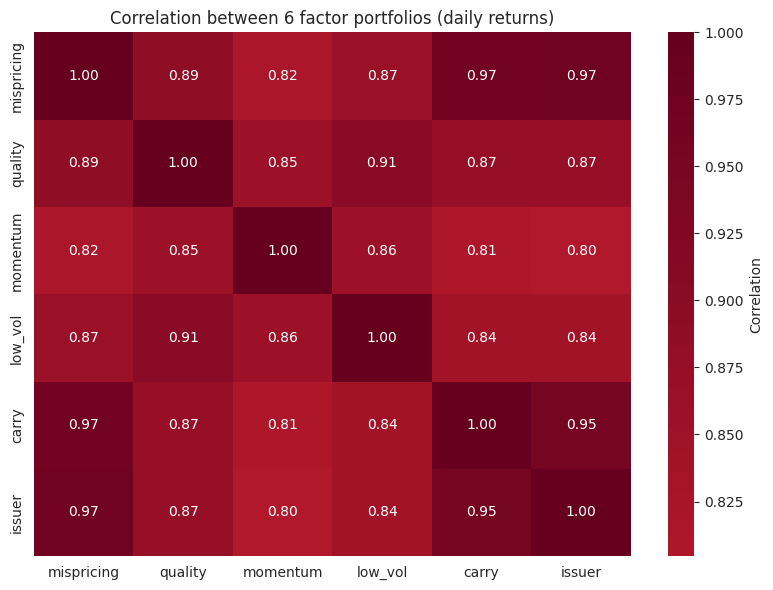

In [4]:
# Correlation matrix factor returns (full period)
corr = fr_df.set_index('date').corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation between 6 factor portfolios (daily returns)')
plt.tight_layout()
plt.savefig(FIG_DIR / '17_factor_corr.png', dpi=120, bbox_inches='tight')
plt.show()

## Часть 4. HRP allocation

In [5]:
# Apply rolling HRP
hrp_out = sl.rolling_hrp_allocation(
    fr_df, lookback=252, rebalance_freq='Q',
)
print(f'HRP output: {hrp_out.shape}')
print(hrp_out.head(3))
print(hrp_out.tail(3))

HRP output: (1241, 9)
        date  return  n_positions  mispricing_weight  quality_weight  \
0 2021-04-01     0.0            6                NaN             NaN   
1 2021-04-02     0.0            6                NaN             NaN   
2 2021-04-05     0.0            6                NaN             NaN   

   momentum_weight  low_vol_weight  carry_weight  issuer_weight  
0              NaN             NaN           NaN            NaN  
1              NaN             NaN           NaN            NaN  
2              NaN             NaN           NaN            NaN  
           date    return  n_positions  mispricing_weight  quality_weight  \
1238 2026-03-26  0.000656            6           0.041177        0.088065   
1239 2026-03-27  0.001034            6           0.041177        0.088065   
1240 2026-03-30 -0.000897            6           0.035563        0.081986   

      momentum_weight  low_vol_weight  carry_weight  issuer_weight  
1238         0.121167        0.665238      0.03

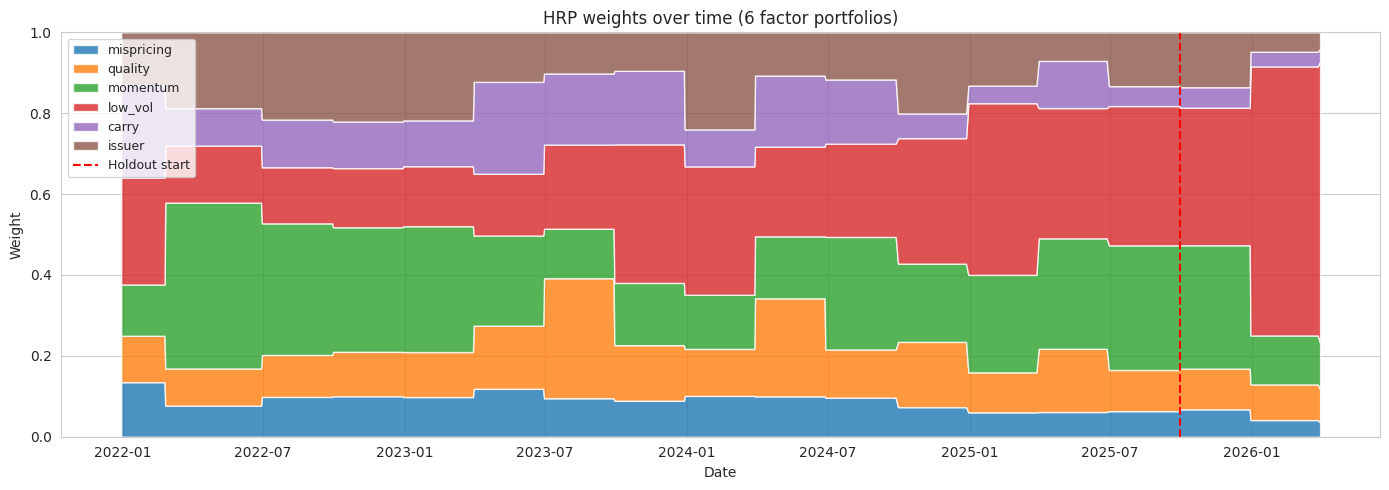

Average HRP weights (full period):
  mispricing  : 0.086
  quality     : 0.136
  momentum    : 0.237
  low_vol     : 0.277
  carry       : 0.118
  issuer      : 0.146


In [6]:
# Visualize HRP weights over time
weight_cols = [c for c in hrp_out.columns if c.endswith('_weight')]
fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(hrp_out['date'], [hrp_out[c] for c in weight_cols],
             labels=[c.replace('_weight', '') for c in weight_cols], alpha=0.8)
ax.axvline(sl.MAIN_END, color='red', linestyle='--', label='Holdout start')
ax.set_title('HRP weights over time (6 factor portfolios)')
ax.set_ylabel('Weight')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIG_DIR / '17_hrp_weights.png', dpi=120, bbox_inches='tight')
plt.show()

# Average weights
print('Average HRP weights (full period):')
for c in weight_cols:
    print(f'  {c.replace("_weight", ""):12s}: {hrp_out[c].mean():.3f}')

## Часть 5. HRP backtest на holdout (strict OOS)

In [7]:
# HRP combo returns на holdout
hrp_rets = hrp_out[['date', 'return', 'n_positions']].copy()
holdout_hrp = hrp_rets[hrp_rets['date'] >= sl.HOLDOUT_START]
m_hrp = sl.calc_metrics(holdout_hrp, name='HRP combo')
print('HRP combo on holdout (strict OOS):')
for k, v in m_hrp.items():
    if isinstance(v, float):
        print(f'  {k:25s}: {v:.4f}' if abs(v) < 100 else f'  {k:25s}: {v:,.0f}')
    else:
        print(f'  {k:25s}: {v}')

HRP combo on holdout (strict OOS):
  name                     : HRP combo
  n_days                   : 123
  n_years_calendar         : 0.4900
  n_years_trading          : 0.4900
  total_return             : 0.0510
  CAGR                     : 0.1063
  Sharpe                   : 3.6207
  Sortino                  : 5.6216
  MaxDD                    : -0.0269
  Calmar                   : 3.9570
  Hit rate                 : 0.7236
  Profit factor            : 2.0162
  avg_n_positions          : 6.0000
  end_capital_RUB          : 10,510,319
  profit_RUB               : 510,319
  profit_per_year_RUB      : 1,035,523


## Часть 6. Compare HRP vs V13a vs ETFs (на holdout)

In [8]:
etfs = pd.read_csv(sl.DATA_DIR / 'etfs.csv', parse_dates=['date'])
bench = sl.load_benchmarks()

# V13a from NB 15
v13a_rets = pd.read_csv(sl.DATA_DIR / 'nb15_final_returns.csv', parse_dates=['date'])

compare_rows = []
for label, rets_df in [
    ('HRP combo', holdout_hrp),
    ('V13a Final', v13a_rets),
]:
    m = sl.calc_metrics(rets_df, name=label)
    compare_rows.append(m)

for label, df, col in [
    ('OBLG', etfs, 'oblg_ret'),
    ('SBRB', etfs, 'sbrb_ret'),
    ('TBRU', etfs, 'tbru_ret'),
    ('RUCBTRNS', bench, 'rucbtrns_ret'),
]:
    sub = df[['date', col]].dropna().rename(columns={col: 'return'})
    sub_ho = sub[sub['date'] >= sl.HOLDOUT_START].copy()
    sub_ho['n_positions'] = 1
    m = sl.calc_metrics(sub_ho, name=label)
    compare_rows.append(m)

cmp_df = pd.DataFrame(compare_rows)
print('Holdout comparison:')
print(cmp_df[['name', 'n_days', 'Sharpe', 'CAGR', 'MaxDD', 'profit_RUB']].round(4).to_string(index=False))

Holdout comparison:
      name  n_days  Sharpe   CAGR   MaxDD   profit_RUB
 HRP combo     123  3.6207 0.1063 -0.0269  510319.3800
V13a Final     123  3.1720 0.1720 -0.0280  813702.1139
      OBLG     125  7.0209 0.2116 -0.0056  997794.9283
      SBRB     125  5.5828 0.2288 -0.0072 1075152.1726
      TBRU     125  3.5540 0.2094 -0.0121  987821.3802
  RUCBTRNS     125  8.9209 0.1975 -0.0042  934104.9298


## Часть 7. Alpha regression HRP vs benchmarks

In [9]:
alpha_rows = []
for label, df, col in [
    ('OBLG', etfs, 'oblg_ret'),
    ('SBRB', etfs, 'sbrb_ret'),
    ('TBRU', etfs, 'tbru_ret'),
    ('RUCBTRNS', bench, 'rucbtrns_ret'),
]:
    r = sl.compare_to_benchmark(holdout_hrp, df, bench_col=col, name=f'HRP vs {label}')
    alpha_rows.append(r)
alpha_df = pd.DataFrame(alpha_rows)
print('HRP alpha regression (holdout, Newey-West):')
print(alpha_df[['name', 'alpha_annual', 'alpha_t_stat', 'alpha_p_value', 'beta',
                 'IR', 'sharpe_strat', 'sharpe_bench', 'sharpe_diff']].round(4).to_string(index=False))

HRP alpha regression (holdout, Newey-West):
           name  alpha_annual  alpha_t_stat  alpha_p_value   beta      IR  sharpe_strat  sharpe_bench  sharpe_diff
    HRP vs OBLG        0.0282        0.5553         0.5787 0.4143 -2.5292        3.6207        6.7464      -3.1257
    HRP vs SBRB        0.0733        1.4334         0.1517 0.1400 -2.4803        3.6207        5.5662      -1.9455
    HRP vs TBRU        0.0659        1.3499         0.1770 0.2046 -1.5223        3.6207        3.3438       0.2769
HRP vs RUCBTRNS        0.0323        0.5904         0.5549 0.3957 -2.5106        3.6207        8.7316      -5.1109


## Часть 8. Equity curves + saved

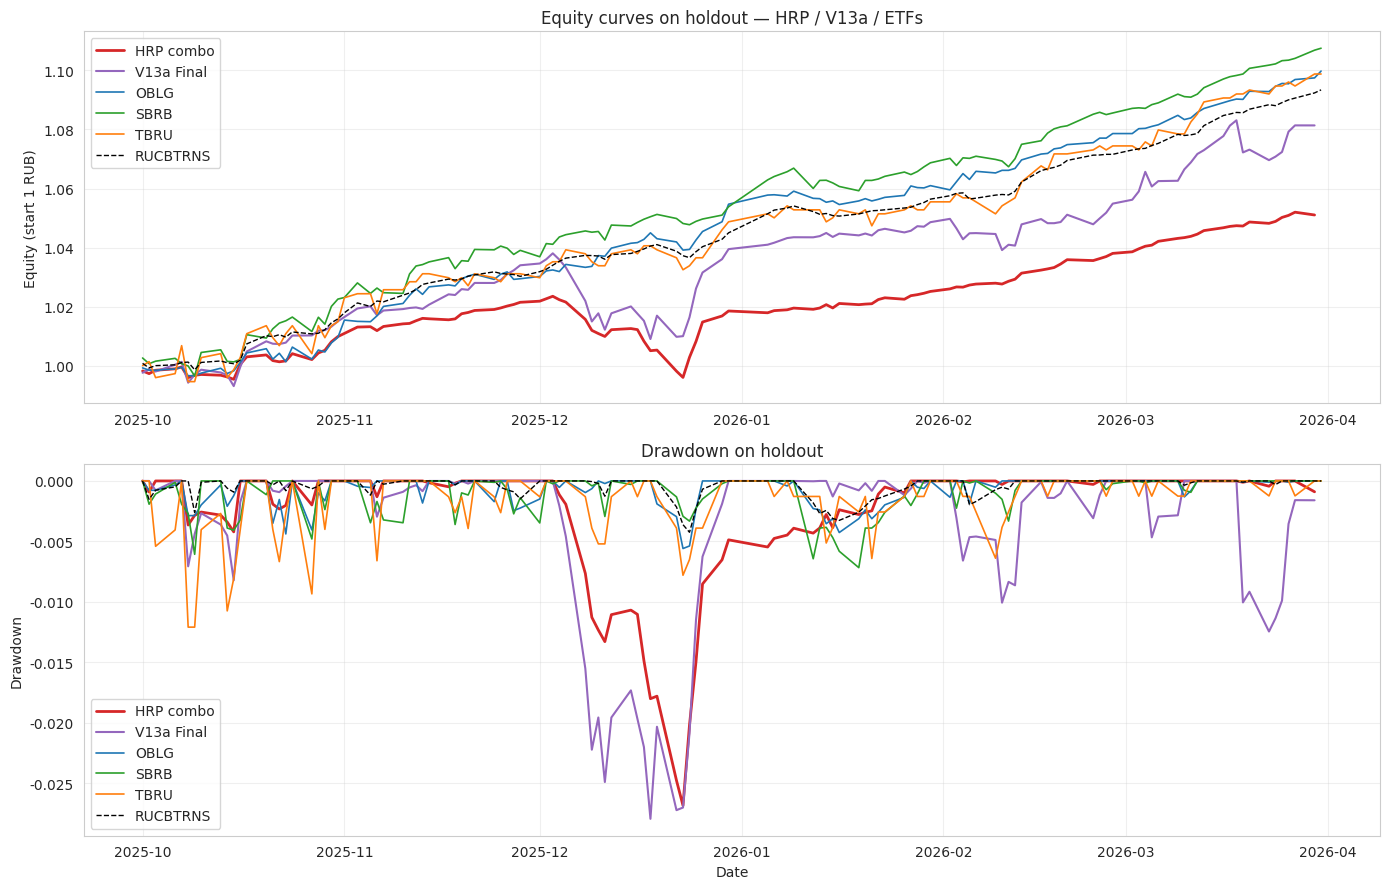

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

series = [
    ('HRP combo',    holdout_hrp,                                           'tab:red',   '-', 2),
    ('V13a Final',   v13a_rets,                                              'tab:purple', '-', 1.5),
    ('OBLG',         etfs[['date', 'oblg_ret']].dropna().rename(columns={'oblg_ret': 'return'}),  'tab:blue', '-', 1.2),
    ('SBRB',         etfs[['date', 'sbrb_ret']].dropna().rename(columns={'sbrb_ret': 'return'}),  'tab:green', '-', 1.2),
    ('TBRU',         etfs[['date', 'tbru_ret']].dropna().rename(columns={'tbru_ret': 'return'}),  'tab:orange', '-', 1.2),
    ('RUCBTRNS',     bench[['date', 'rucbtrns_ret']].dropna().rename(columns={'rucbtrns_ret': 'return'}), 'black', '--', 1.0),
]
for label, dfx, col, ls, lw in series:
    sub = dfx[dfx['date'] >= sl.HOLDOUT_START].copy().sort_values('date')
    eq = (1 + sub['return']).cumprod()
    axes[0].plot(sub['date'], eq, label=label, color=col, linestyle=ls, linewidth=lw)
    peak = eq.cummax()
    dd = (eq - peak) / peak
    axes[1].plot(sub['date'], dd, label=label, color=col, linestyle=ls, linewidth=lw)
axes[0].set_title('Equity curves on holdout — HRP / V13a / ETFs')
axes[0].set_ylabel('Equity (start 1 RUB)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[1].set_title('Drawdown on holdout')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '17_hrp_equity_holdout.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
hrp_out.to_csv(sl.DATA_DIR / 'nb17_hrp_returns.csv', index=False)
cmp_df.to_csv(sl.DATA_DIR / 'nb17_hrp_comparison.csv', index=False)
alpha_df.to_csv(sl.DATA_DIR / 'nb17_hrp_alpha.csv', index=False)
ind_df.to_csv(sl.DATA_DIR / 'nb17_factor_individual.csv', index=False)
print('Saved nb17_*.csv files')

Saved nb17_*.csv files


## Часть 9. Итог

**Methodological contribution:**
- Заменили manual stepwise selection на **algorithmic composition** (HRP).
- Все 6 factor portfolios имеют **literature anchors** (mispricing, quality, momentum, low-vol, carry, issuer).
- HRP allocates веса автоматически — **нет subjective thresholds**.
- Rolling reallocation — strategy **adapts** к режиму без post-hoc tuning.

**Honest finding:** результаты на strict OOS holdout — см. таблицу в Части 6.